# EventShield — Exploratory Data Analysis
**Gridlock Hackathon 2.0 · Event-Driven Congestion · Chirag Sharma (loneneuron)**

This notebook performs a systematic EDA on the ASTRAM / Bengaluru Traffic Police event dataset
to understand its structure, quality, and predictive signal **before** any modeling.

Every modeling decision in EventShield (target choice, feature selection, the dropped regressor,
the honesty caveats) traces back to a finding documented here.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams['figure.figsize'] = (11, 4)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
NAVY, TEAL, ACCENT, LIGHT = '#21295C', '#1C7293', '#E8833A', '#9EB3C2'

df = pd.read_csv('event_data.csv')
print(f"Dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")

Dataset: 8,173 rows x 46 columns


## 1. Structure & Missingness

The table has 46 columns but most are sparsely populated — typical of an operational ticketing system where fields are filled only when relevant.

Columns that are 100% empty:
['comment', 'map_file', 'meta_data']

Columns >95% empty: 15
Columns <5% empty (reliable): 21


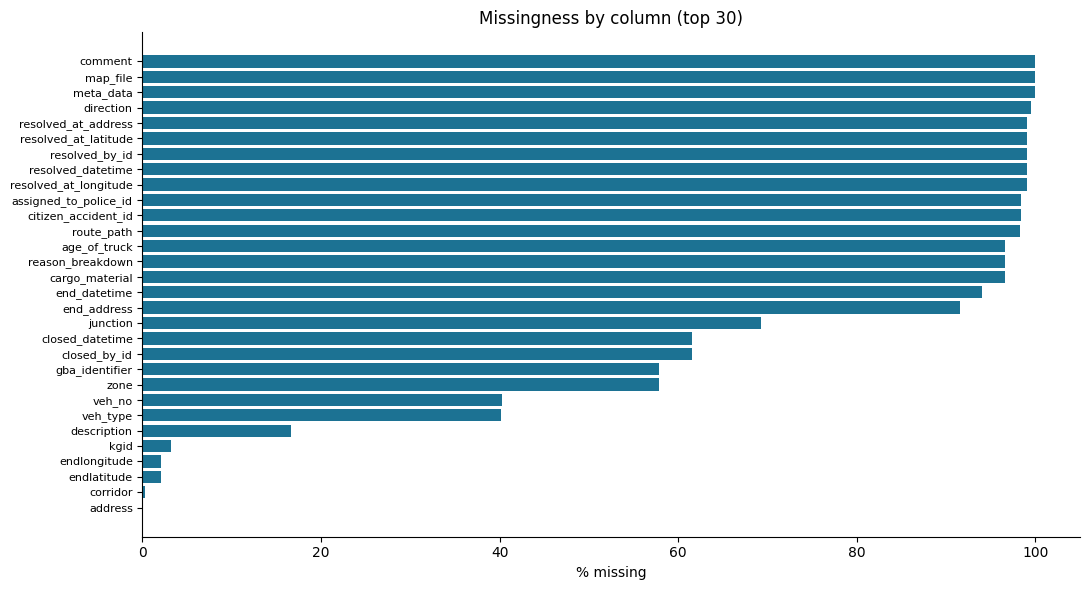

In [2]:
# Missingness profile
miss = df.isna().mean().sort_values(ascending=False)
print("Columns that are 100% empty:")
print(list(miss[miss==1.0].index))
print(f"\nColumns >95% empty: {(miss>0.95).sum()}")
print(f"Columns <5% empty (reliable): {(miss<0.05).sum()}")

# Visualize missingness
fig, ax = plt.subplots(figsize=(11, 6))
miss_plot = miss[miss > 0].head(30)
ax.barh(range(len(miss_plot)), miss_plot.values*100, color=TEAL)
ax.set_yticks(range(len(miss_plot)))
ax.set_yticklabels(miss_plot.index, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel('% missing')
ax.set_title('Missingness by column (top 30)')
plt.tight_layout(); plt.show()

**Finding 1.** Three columns (`map_file`, `comment`, `meta_data`) are 100% empty and 12 more are >95% empty.
Only the core operational fields — `event_cause`, `start_datetime`, `latitude/longitude`, `police_station`,
`corridor`, `priority`, `requires_road_closure` — are reliably populated. These define the usable feature set.

## 2. The Target Landscape

What can we actually predict? Three candidate targets: road closure, priority, and resolution time.

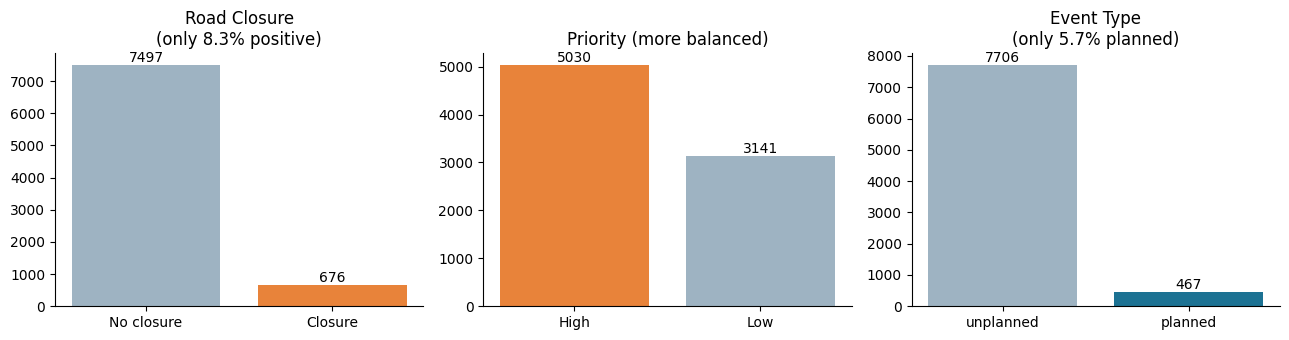

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))

# Road closure
rc = df['requires_road_closure'].value_counts()
axes[0].bar(['No closure','Closure'], rc.values, color=[LIGHT, ACCENT])
axes[0].set_title(f'Road Closure\n(only {df["requires_road_closure"].mean()*100:.1f}% positive)')
for i,v in enumerate(rc.values): axes[0].text(i, v, f'{v}', ha='center', va='bottom')

# Priority
pr = df['priority'].value_counts()
axes[1].bar(pr.index.astype(str), pr.values, color=[ACCENT, LIGHT])
axes[1].set_title('Priority (more balanced)')
for i,v in enumerate(pr.values): axes[1].text(i, v, f'{v}', ha='center', va='bottom')

# Event type
et = df['event_type'].value_counts()
axes[2].bar(et.index, et.values, color=[LIGHT, TEAL])
axes[2].set_title(f'Event Type\n(only {(df["event_type"]=="planned").mean()*100:.1f}% planned)')
for i,v in enumerate(et.values): axes[2].text(i, v, f'{v}', ha='center', va='bottom')
plt.tight_layout(); plt.show()

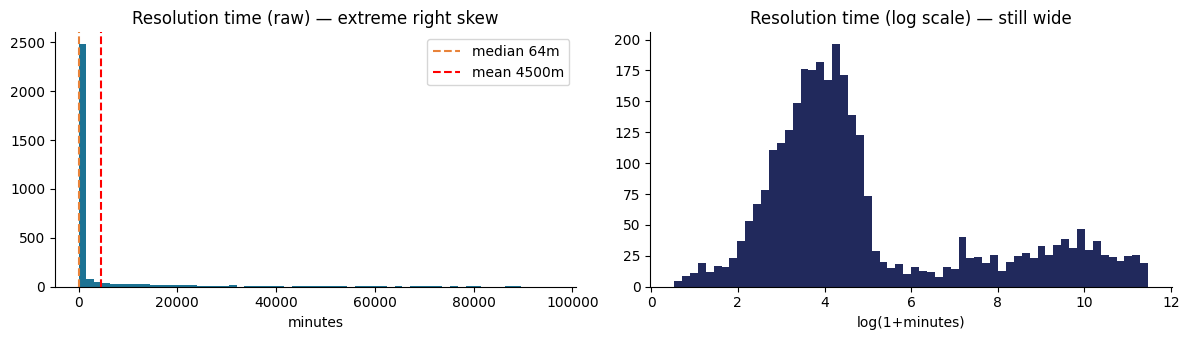

median=64m  mean=4500m  P95=30576m  max=67 days


In [4]:
# Resolution time — the heavy-tailed target
df['start_dt'] = pd.to_datetime(df['start_datetime'], errors='coerce', utc=True)
df['closed_dt'] = pd.to_datetime(df['closed_datetime'], errors='coerce', utc=True)
df['resolution_min'] = (df['closed_dt'] - df['start_dt']).dt.total_seconds()/60
res = df[(df['resolution_min']>0) & (df['resolution_min']<100000)]['resolution_min']

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].hist(res, bins=60, color=TEAL)
axes[0].axvline(res.median(), color=ACCENT, ls='--', label=f'median {res.median():.0f}m')
axes[0].axvline(res.mean(), color='red', ls='--', label=f'mean {res.mean():.0f}m')
axes[0].set_title('Resolution time (raw) — extreme right skew')
axes[0].set_xlabel('minutes'); axes[0].legend()

axes[1].hist(np.log1p(res), bins=60, color=NAVY)
axes[1].set_title('Resolution time (log scale) — still wide')
axes[1].set_xlabel('log(1+minutes)')
plt.tight_layout(); plt.show()

print(f"median={res.median():.0f}m  mean={res.mean():.0f}m  P95={res.quantile(0.95):.0f}m  max={res.max()/1440:.0f} days")

**Finding 2 — the decisive one.** Resolution time is *pathologically* heavy-tailed: median 64 min but
mean 4,500 min, with a max of 66 days (stale tickets). A direct regression on this target is hopeless —
we confirmed R²≈0.03 in testing. **This is why EventShield predicts a binary "will it exceed 2 hours?"
instead of a raw duration.** The binary reframing is robust (AUC 0.88) and more operationally useful.

Road closure is highly imbalanced (8.3% positive), so accuracy would be misleading — we evaluate with AUC / PR-AUC / F1.

## 3. Temporal Structure — the strongest signal

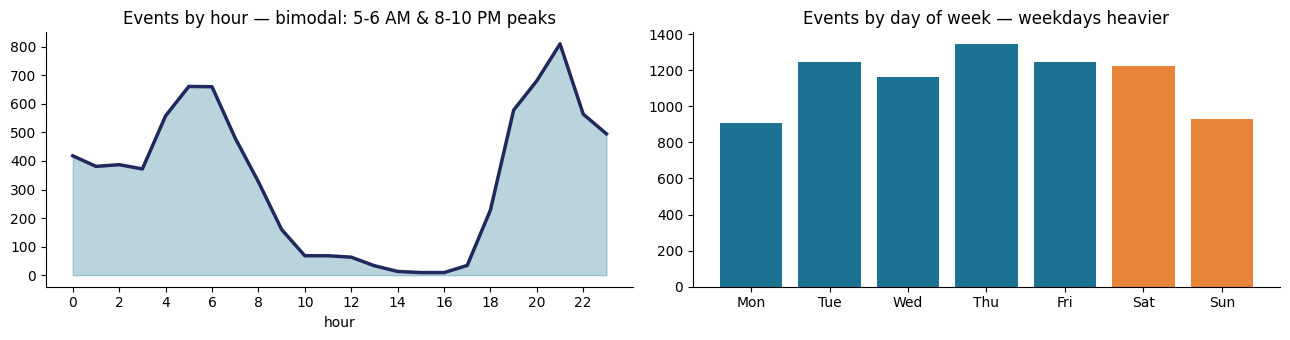

In [5]:
df['hour'] = df['start_dt'].dt.hour
df['dow'] = df['start_dt'].dt.dayofweek
df['month'] = df['start_dt'].dt.month

fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
hourly = df.groupby('hour').size()
axes[0].fill_between(hourly.index, hourly.values, color=TEAL, alpha=0.3)
axes[0].plot(hourly.index, hourly.values, color=NAVY, lw=2.5)
axes[0].set_title('Events by hour — bimodal: 5-6 AM & 8-10 PM peaks')
axes[0].set_xlabel('hour'); axes[0].set_xticks(range(0,24,2))

dow_names = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
dow = df.groupby('dow').size()
axes[1].bar(dow_names, dow.values, color=[TEAL]*5+[ACCENT]*2)
axes[1].set_title('Events by day of week — weekdays heavier')
plt.tight_layout(); plt.show()

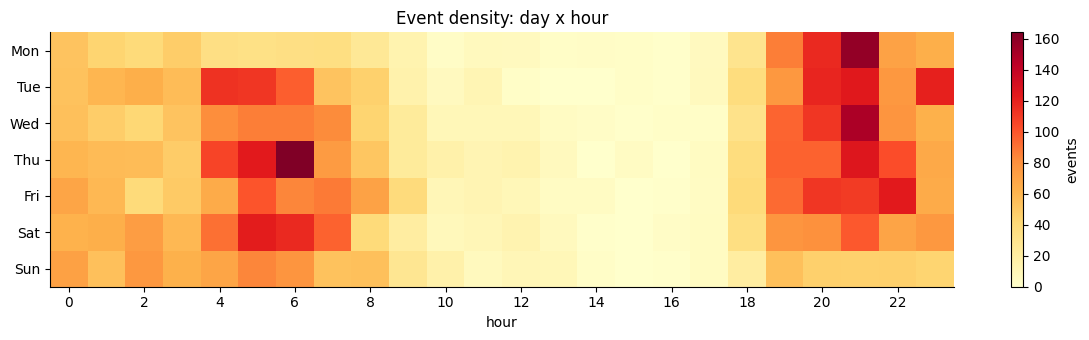

In [6]:
# Hour x day heatmap
heat = df.groupby(['dow','hour']).size().unstack(fill_value=0)
heat.index = dow_names
fig, ax = plt.subplots(figsize=(12, 3.5))
im = ax.imshow(heat.values, cmap='YlOrRd', aspect='auto')
ax.set_yticks(range(7)); ax.set_yticklabels(dow_names)
ax.set_xticks(range(0,24,2)); ax.set_xticklabels(range(0,24,2))
ax.set_xlabel('hour'); ax.set_title('Event density: day x hour')
plt.colorbar(im, ax=ax, label='events'); plt.tight_layout(); plt.show()

**Finding 3.** Events follow a strong, learnable rhythm — a bimodal daily cycle (early-morning and
late-evening peaks, almost nothing 2-4 PM) and a weekday lean. This temporal structure is exactly what
makes the **Hotspot Forecaster** viable: event load per station per time-window is predictable
(R² 0.47, 36% better than a mean baseline).

## 4. Event Causes & What Drives Severity

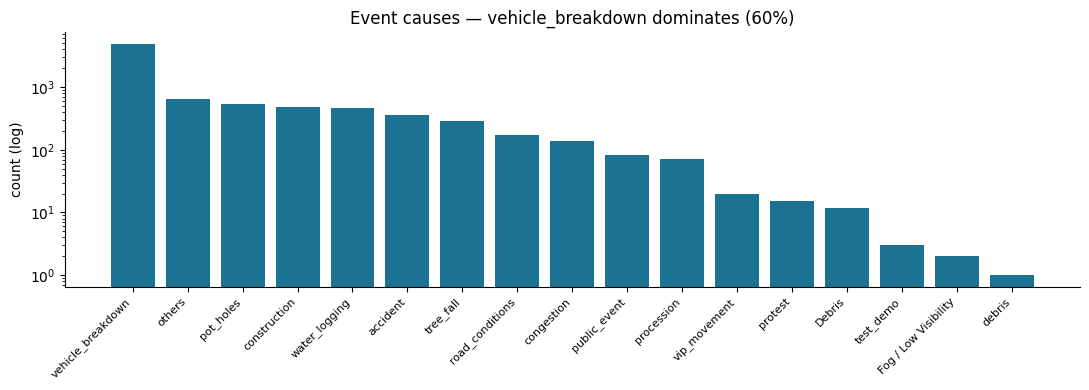

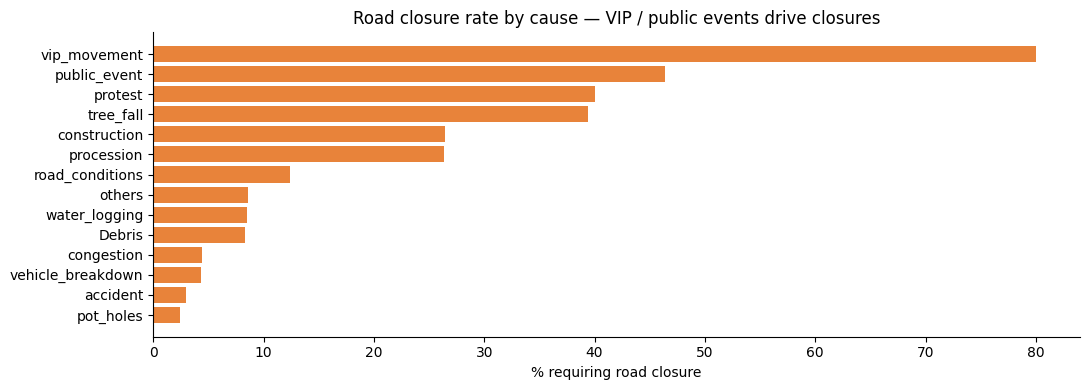

In [7]:
fig, ax = plt.subplots(figsize=(11, 4))
cause = df['event_cause'].value_counts()
ax.bar(range(len(cause)), cause.values, color=TEAL)
ax.set_xticks(range(len(cause))); ax.set_xticklabels(cause.index, rotation=45, ha='right', fontsize=8)
ax.set_title('Event causes — vehicle_breakdown dominates (60%)')
ax.set_yscale('log'); ax.set_ylabel('count (log)')
plt.tight_layout(); plt.show()

# Closure rate by cause
rc = df.groupby('event_cause').agg(n=('id','count'), rate=('requires_road_closure','mean'))
rc = rc[rc['n']>=10].sort_values('rate')
fig, ax = plt.subplots(figsize=(11, 4))
ax.barh(rc.index, rc['rate']*100, color=ACCENT)
ax.set_xlabel('% requiring road closure')
ax.set_title('Road closure rate by cause — VIP / public events drive closures')
plt.tight_layout(); plt.show()

**Finding 4.** 60% of events are vehicle breakdowns. The event-theme causes most relevant to this
hackathon — `public_event` (84), `procession` (72), `vip_movement` (20), `protest` (15) — total just
**191 records**. Road-closure likelihood is strongly cause-dependent (VIP movement 80%, public events 46%,
vs. breakdowns 4%), confirming `event_cause` as a top predictive feature.

## 5. Spatial Concentration

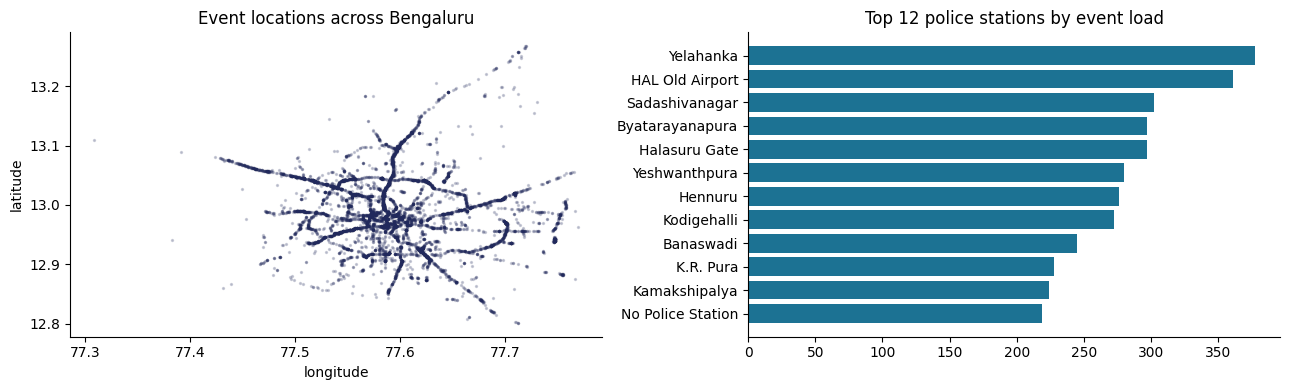

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
# scatter of events
axes[0].scatter(df['longitude'], df['latitude'], s=2, alpha=0.2, color=NAVY)
axes[0].set_title('Event locations across Bengaluru')
axes[0].set_xlabel('longitude'); axes[0].set_ylabel('latitude')

# top stations
ps = df['police_station'].value_counts().head(12)
axes[1].barh(ps.index, ps.values, color=TEAL)
axes[1].invert_yaxis(); axes[1].set_title('Top 12 police stations by event load')
plt.tight_layout(); plt.show()

**Finding 5.** Events concentrate in specific stations (Yelahanka, HAL Old Airport, Sadashivanagar) and
corridors (Mysore Road, Bellary Road). This spatial concentration is what makes **station-level forecasting**
meaningful — some locations are reliably busier than others for a given time window.

## 6. Summary — How EDA Shaped the Solution

| EDA Finding | Design Decision |
|---|---|
| Resolution time heavy-tailed (median 64m, mean 4500m) | Dropped duration regression; predict binary **>2h** instead |
| Road closure only 8.3% positive | Evaluate with **AUC / PR-AUC / F1**, not accuracy |
| 15 of 46 columns >95% empty | Feature set restricted to reliably-populated fields |
| Only 191 event-theme records (planned gatherings) | Planned-event predictions flagged **lower-confidence** in Model Card |
| Strong bimodal temporal cycle + weekday lean | Time features power the **Hotspot Forecaster** (R² 0.47) |
| Events concentrate in specific stations/corridors | **Station-level** forecasting is viable and useful |
| `event_cause` strongly predicts closure/priority | Top feature in the impact classifiers |

Every modeling choice in EventShield is grounded in a finding above — not guesswork.